# Melanoma Skin Cancer Classification — CNN from Scratch (PyTorch)

**Dataset:** Melanoma Skin Cancer Dataset of 10,000 Images (Kaggle)
**Task:** Binary Classification — Benign vs. Malignant
**Model:** Custom Convolutional Neural Network (built from scratch, no pretrained weights)
**Framework:** PyTorch
**Environment:** Google Colab (GPU runtime)


## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Dataset Path

In [4]:
import os

DATA_DIR = "/content/drive/MyDrive/CNN Project/melanoma_cancer_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))
if os.path.exists(TRAIN_DIR):
    print("Train classes:", os.listdir(TRAIN_DIR))
if os.path.exists(TEST_DIR):
    print("Test classes:", os.listdir(TEST_DIR))


Train dir exists: True
Test dir exists: True
Train classes: ['benign', 'malignant']
Test classes: ['malignant', 'benign']


## 3. Imports and Setup

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


Using device: cuda


## 4. Data Loading and Transforms

We resize all images to 128x128 pixels (keeps training fast on Colab's free
GPU while still preserving enough detail for the CNN to learn from), and
normalize pixel values. For the training set, we add mild data augmentation
(random flips and rotations) — this artificially increases the diversity of
training images and helps prevent the model from overfitting.

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

# Training transforms: include light augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Test transforms: no augmentation, just resize + normalize
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Class-to-index mapping:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))


Classes: ['benign', 'malignant']
Class-to-index mapping: {'benign': 0, 'malignant': 1}
Training images: 9605
Test images: 1000


### 4.1 Visualize Some Sample Images

Always good practice to actually look at your data before training on it.

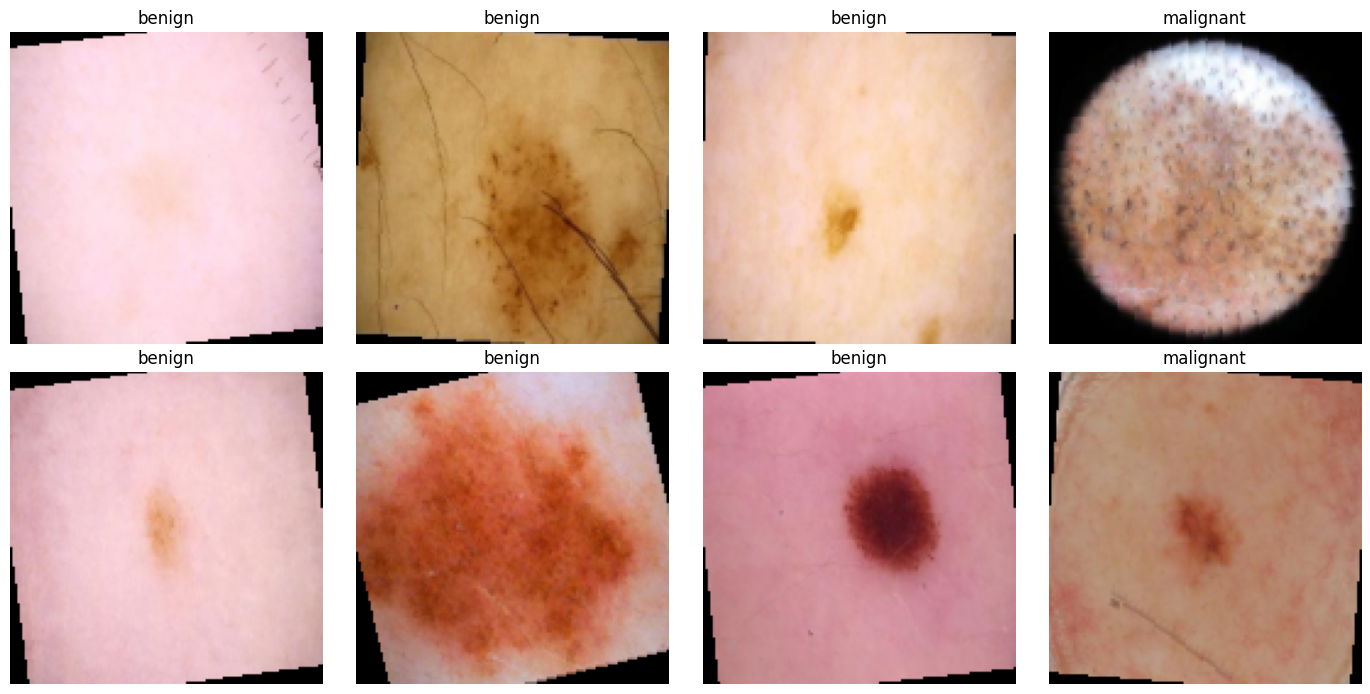

In [7]:
def imshow(img_tensor):
    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

images, labels = next(iter(train_loader))
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imshow(images[i]))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Building the CNN from Scratch

We design a simple but effective CNN architecture:

- **3 convolutional blocks**, each with: Conv2D → ReLU → BatchNorm → MaxPool

In [8]:
class MelanomaCNN(nn.Module):
    def __init__(self):
        super(MelanomaCNN, self).__init__()

        # Block 1: 3 -> 32 channels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 32 -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 64 -> 128 channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)   # halves spatial dimensions each time
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # After 3 pooling layers: 128 -> 64 -> 32 -> 16, so feature map is 16x16 with 128 channels
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 1)   # single output: probability of malignant

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # -> 64x64
        x = self.pool(self.relu(self.bn2(self.conv2(x))))   # -> 32x32
        x = self.pool(self.relu(self.bn3(self.conv3(x))))   # -> 16x16

        x = x.view(x.size(0), -1)   # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)             # raw logit output (sigmoid applied in loss function)
        return x

model = MelanomaCNN().to(device)
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


MelanomaCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

Total trainable parameters: 8,482,817


## 6. Training Setup

In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15


## 7. Training Loop

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)   # shape (batch, 1) to match model output

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [11]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


Epoch 1/15 | Train Loss: 0.5495, Train Acc: 0.8387 | Test Loss: 0.3171, Test Acc: 0.8560
Epoch 2/15 | Train Loss: 0.3199, Train Acc: 0.8691 | Test Loss: 0.2541, Test Acc: 0.8970
Epoch 3/15 | Train Loss: 0.3128, Train Acc: 0.8684 | Test Loss: 0.2553, Test Acc: 0.8950
Epoch 4/15 | Train Loss: 0.3054, Train Acc: 0.8777 | Test Loss: 0.2388, Test Acc: 0.9060
Epoch 5/15 | Train Loss: 0.2882, Train Acc: 0.8784 | Test Loss: 0.2328, Test Acc: 0.9000
Epoch 6/15 | Train Loss: 0.2872, Train Acc: 0.8824 | Test Loss: 0.2283, Test Acc: 0.8980
Epoch 7/15 | Train Loss: 0.2797, Train Acc: 0.8871 | Test Loss: 0.2447, Test Acc: 0.9040
Epoch 8/15 | Train Loss: 0.2637, Train Acc: 0.8954 | Test Loss: 0.2374, Test Acc: 0.9110
Epoch 9/15 | Train Loss: 0.2673, Train Acc: 0.8914 | Test Loss: 0.2406, Test Acc: 0.9020
Epoch 10/15 | Train Loss: 0.2667, Train Acc: 0.8967 | Test Loss: 0.2207, Test Acc: 0.9110
Epoch 11/15 | Train Loss: 0.2566, Train Acc: 0.8989 | Test Loss: 0.2357, Test Acc: 0.9100
Epoch 12/15 | Train

## 8. Learning Curves

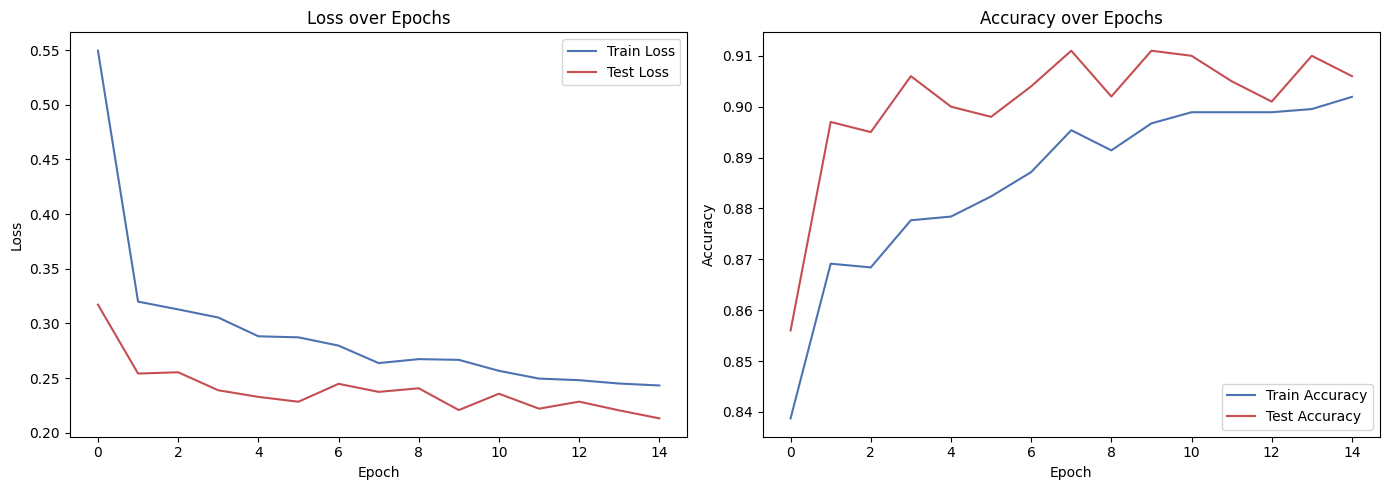

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color="#4C72B0")
axes[0].plot(history["test_loss"], label="Test Loss", color="#C44E52")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Accuracy", color="#4C72B0")
axes[1].plot(history["test_acc"], label="Test Accuracy", color="#C44E52")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Final Evaluation

We now compute detailed evaluation metrics on the test set: confusion
matrix, precision, recall, F1-score, and ROC-AUC.

In [13]:
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("Class mapping:", train_dataset.class_to_idx)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {auc:.4f}")


Class mapping: {'benign': 0, 'malignant': 1}

Classification Report:
              precision    recall  f1-score   support

      benign       0.88      0.93      0.91       500
   malignant       0.93      0.88      0.90       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC: 0.9693


### 9.1 Confusion Matrix

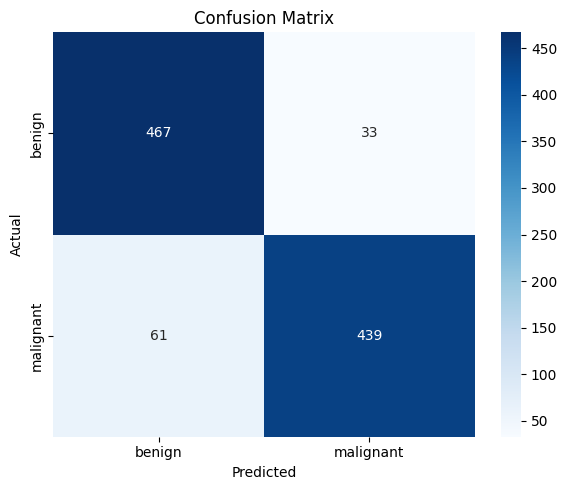

In [14]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


### 9.2 ROC Curve

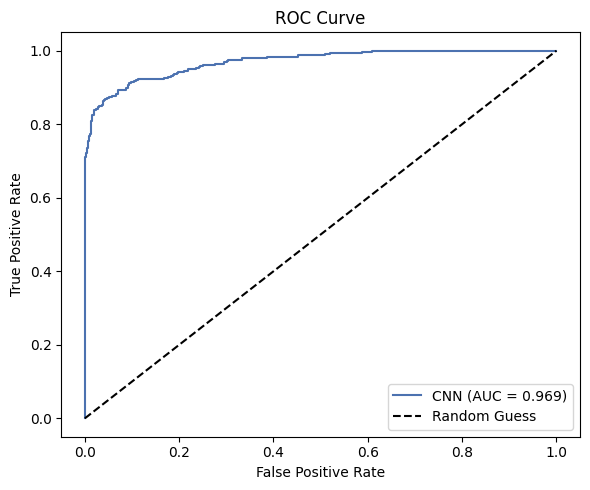

In [15]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"CNN (AUC = {auc:.3f})", color="#4C72B0")
ax.plot([0, 1], [0, 1], "k--", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()


### 9.3 Sample Predictions

Visual sanity check — let's look at some actual test images along with the
model's predictions vs. the true labels.

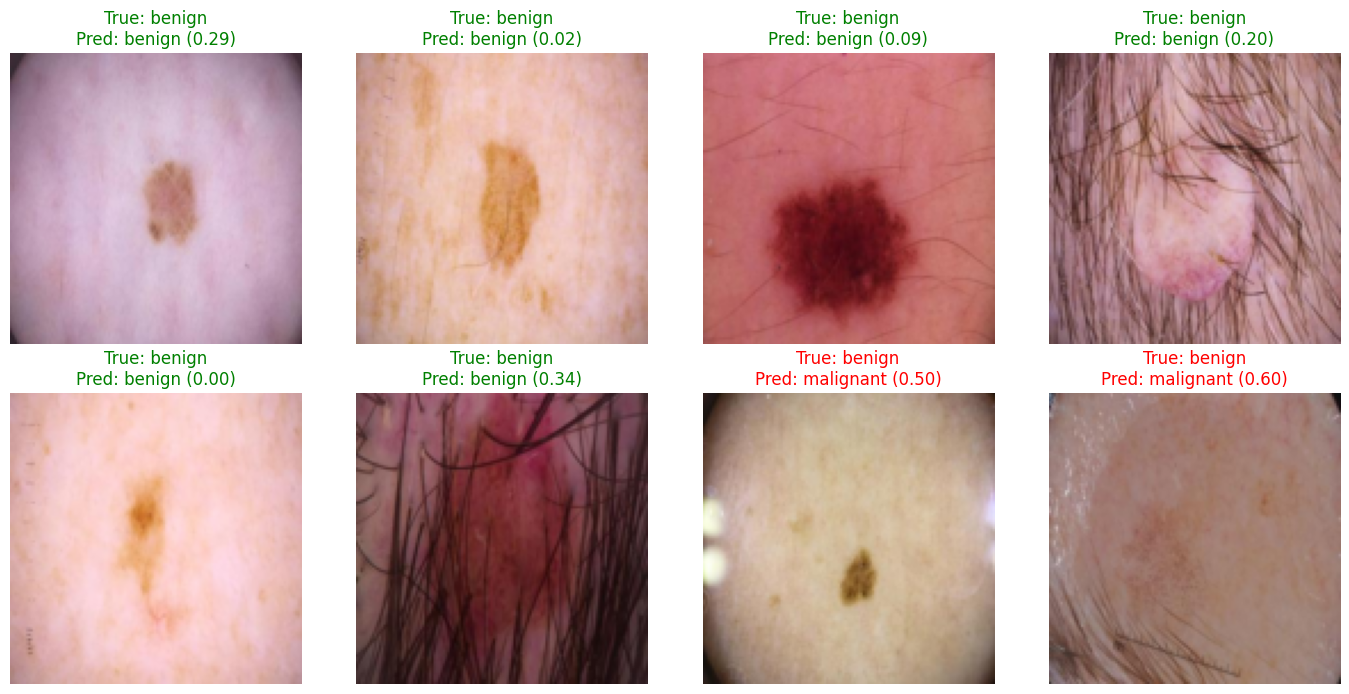

In [16]:
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    probs = torch.sigmoid(outputs).cpu().numpy().flatten()
    preds = (probs > 0.5).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imshow(images[i]))
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({probs[i]:.2f})", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 10. Save the Trained Model

In [18]:
MODEL_SAVE_PATH = os.path.join(DATA_DIR, "melanoma_cnn_model.pth")
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")


Model saved to: /content/drive/MyDrive/CNN Project/melanoma_cancer_dataset/melanoma_cnn_model.pth
